
# TrustCV Deep Learning Showcase (No Indexable* helpers)
This notebook is the **same story and same experiments** as the previous “showcase”, but it **removes** the `IndexableDict / IndexableList / IndexableTFDataset` helpers.

We rely on what you described in your library:

- **`UniversalCVRunner → SklearnAdapter.create_data_splits(...)`** recursively slices **dicts** and **lists/tuples** using the fold indices (and uses `.iloc` for pandas objects).
- **`KerasSkWrap` / `KerasRegressorWrap`** accept **dict/list inputs** and pass them directly into Keras.
- **Dict outputs** are handled via `output_key` / `output_index` selection (no extra wrapping needed), as long as each value supports `v[idx]`.

## How to read the results (the “numbers that matter”)
Across all experiments, interpret the outputs using three kinds of evidence:

1. **Patient overlap (leakage sanity check)**  
   In group-safe CV, the number of patient IDs shared between train/test in each fold should be **0**.

2. **Per-fold metrics stability**  
   Look at the spread across folds (std). Big std often means the model depends on a subset of patients or labels are imbalanced.

3. **Prevalence per fold** (especially for multilabel)  
   If the label prevalence differs a lot across folds, macro metrics will swing more than micro metrics.

---



## Feature glossary (units, typical ranges, clinical interpretation)

| Feature | Unit | Typical range (adult) | One-line clinical interpretation |
|---|---:|---:|---|
| **age** | years | ~18–90+ | Older age generally increases cardiovascular risk (events, HF, stroke). |
| **bmi** | kg/m² | ~18–40+ | Higher BMI is associated with cardiometabolic risk (HTN, diabetes, dyslipidemia). |
| **sbp** | mmHg | ~90–180+ | Elevated systolic BP increases risk of MI, stroke, HF, and kidney disease. |
| **ef** | % | ~35–70 | Left ventricular ejection fraction; lower EF suggests impaired pump function and higher HF/event risk. |
| **lvmass** (LV mass index) | g/m² | ~50–150 | Higher LV mass indicates remodeling/LVH, often from chronic pressure overload (e.g., HTN). |
| **af** | 0/1 | 0 or 1 | Atrial fibrillation present; associated with stroke risk and adverse cardiac outcomes. |
| **lvh** | 0/1 | 0 or 1 | Left ventricular hypertrophy flag; marker of structural heart disease and elevated risk. |
| **cond** | 0/1 | 0 or 1 | Conduction abnormality flag (e.g., bundle branch block); may reflect structural/electrical disease. |
| **mace_1y** | 0/1 | 0 or 1 | Major adverse cardiovascular event within 1 year (binary outcome to classify). |
| **ef_drop** | %-points | ~0–20 | Future EF decline magnitude; larger values indicate worsening LV function (regression target). |

**Notes (for this synthetic demo):**
- Ranges are approximate and intended for intuition; real cohorts vary by inclusion criteria and measurement modality.
- `af`, `lvh`, `cond` can co-occur (multi-label setting).
- `ef_drop` is expressed as **percentage-point drop** in EF (e.g., 55% → 48% is a 7-point drop).


In [1]:

# --- Colab install (uncomment in Colab) ---
# !pip -q install trustcv==1.0.5 tensorflow scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    mean_squared_error, r2_score
)

import trustcv
from trustcv import TrustCVValidator, UniversalCVRunner
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap, KerasRegressorWrap
from trustcv.splitters.grouped import StratifiedGroupKFold

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

print("trustcv version:", trustcv.__version__)
print("tf version:", tf.__version__)
print("KerasSkWrap:", KerasSkWrap)


2026-02-28 14:36:30.679495: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 14:36:30.798174: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 14:36:30.941104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-28 14:36:31.080072: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-28 14:36:31.080596: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-28 14:36:31.285938: I tensorflow/core/platform/cpu_feature_guard.cc:

trustcv version: 1.0.6
tf version: 2.16.2
KerasSkWrap: <class 'trustcv.frameworks.tensorflow_sklearn.KerasClassifierWrap'>



## Step 1 — Simulate a small cardiology-like dataset (patient IDs + repeated visits)

**Scenario:** Each patient has multiple visits. If you split by sample (row) instead of by patient, the model can “see” the same patient in train and test.  
This is the classic **patient leakage** problem.

We generate:
- `X_tab`: clinical features (age, BMI, SBP)
- `X_img`: imaging biomarkers (EF, LV mass index)
- `X_dict`: multi-input dict (`{"clinical": ..., "imaging": ...}`)
- `X_list`: multi-input list (`[X_tab, X_img]`)
- `y_main`: binary MACE (1-year)
- `y_multi`: multilabel flags (AF/LVH/Conduction), C=3
- `y_future_ef_drop`: regression target
- `y_multiout`: dict outputs for multi-head model (`{"mace":..., "ef_drop":...}`)

**Judgment numbers:** confirm
- `N_patients` and `visits_per_patient` are correct
- label prevalence is reasonable (not 0% or 100%)


In [3]:

# -------------------------
# Data generation
# -------------------------
N_patients = 200
visits_per_patient = 4
N = N_patients * visits_per_patient

patient_ids = np.repeat(np.arange(N_patients), visits_per_patient)

# Clinical features
age = np.random.normal(65, 10, N)
bmi = np.random.normal(27, 4, N)
sbp = np.random.normal(135, 15, N)

# Imaging biomarkers
ef = np.random.normal(55, 8, N)
lvmass = np.random.normal(90, 20, N)

# Multi-label ECG/echo flags (C=3)
af_flag   = (np.random.rand(N) < 0.25).astype(int)
lvh_flag  = (np.random.rand(N) < 0.30).astype(int)
cond_flag = (np.random.rand(N) < 0.20).astype(int)
y_multi = np.stack([af_flag, lvh_flag, cond_flag], axis=1).astype("int32")

# Binary outcome: 1y MACE risk (depends on age, EF, flags + latent patient effect)
patient_risk = np.random.normal(0, 0.7, N_patients)  # latent patient effect
logit = (
    0.03*(age-60)
    -0.05*(ef-55)
    +0.8*af_flag +0.5*lvh_flag +0.6*cond_flag
    + patient_risk[patient_ids]
)
prob = 1/(1+np.exp(-logit))
y_main = (np.random.rand(N) < prob).astype("int32")

# Regression outcome: future EF drop
y_future_ef_drop = (
    np.maximum(0, 10 - 0.10*(ef-55)) + 2*af_flag + np.random.normal(0, 2, N)
).astype("float32")

# Assemble multi-input X representations
X_tab = np.stack([age, bmi, sbp], axis=1).astype("float32")
X_img = np.stack([ef, lvmass], axis=1).astype("float32")

X_single = np.concatenate([X_tab, X_img], axis=1)  # (N,5) single-array input
X_dict = {"clinical": X_tab, "imaging": X_img}     # dict input (multi-input)
X_list = [X_tab, X_img]                            # list input (multi-input)

# Multi-output y as dict (for multi-output model training)
y_multiout = {"mace": y_main.astype("int32"), "ef_drop": y_future_ef_drop.astype("float32")}

df_preview = pd.DataFrame({
    "patient_id": patient_ids,
    "age": age, "bmi": bmi, "sbp": sbp,
    "ef": ef, "lvmass": lvmass,
    "af": af_flag, "lvh": lvh_flag, "cond": cond_flag,
    "mace_1y": y_main,
    "future_ef_drop": y_future_ef_drop
})
display(df_preview.head(8))

print("Shapes:")
print("  X_single:", X_single.shape)
print("  X_tab   :", X_tab.shape, "X_img:", X_img.shape)
print("  y_main  :", y_main.shape, "y_multi:", y_multi.shape, "y_future:", y_future_ef_drop.shape)
print("  #patients:", len(np.unique(patient_ids)), "N:", len(patient_ids))
print("Label prevalence:")
print("  mace_1y mean:", y_main.mean().round(3))
print("  AF/LVH/COND means:", y_multi.mean(axis=0).round(3))


,patient_id,age,bmi,sbp,ef,lvmass,af,lvh,cond,mace_1y,future_ef_drop
0,0,67.172079,27.968283,150.932512,49.257174,61.376233,0,1,1,1,10.211471
1,0,60.352328,23.596100,130.147276,61.366910,51.535674,0,0,0,0,11.258950
2,0,53.227736,30.455694,135.214308,60.235105,85.096552,0,0,0,0,6.710454
3,0,69.685402,30.076543,148.664166,57.319289,59.631686,0,0,0,0,5.581715
4,1,82.829056,26.249092,159.194673,65.528059,90.924232,0,0,0,0,11.963360
5,1,62.526596,30.362427,145.938554,50.689721,104.978722,0,0,0,1,11.453858
6,1,41.210040,23.698832,133.752423,53.503540,119.882838,0,1,0,0,11.363106
7,1,71.700497,25.028327,155.660025,55.763696,94.027891,0,0,0,1,7.769997


Shapes:
  X_single: (800, 5)
  X_tab   : (800, 3) X_img: (800, 2)
  y_main  : (800,) y_multi: (800, 3) y_future: (800,)
  #patients: 200 N: 800
Label prevalence:
  mace_1y mean: 0.615
  AF/LVH/COND means: [0.25  0.305 0.186]


In [4]:
df =df_preview 

X_tab = df[["age","bmi","sbp"]].to_numpy().astype("float32")
X_img = df[["ef","lvmass"]].to_numpy().astype("float32")

X_single = df[["age","bmi","sbp","ef","lvmass"]].to_numpy().astype("float32")
X_dict = {"clinical": X_tab, "imaging": X_img}
X_list = [X_tab, X_img]

y_main = df["mace_1y"].to_numpy().astype("int32")                      # binary
y_multi = df[["af","lvh","cond"]].to_numpy().astype("int32")           # multilabel (N,3)
y_reg = df["ef"].to_numpy().astype("float32")                     # regression
groups = df["patient_id"].to_numpy()

In [5]:
import pandas as pd

print('--- X_tab (Clinical Features) ---')
display(pd.DataFrame(X_tab, columns=["age","bmi","sbp"]).head())

print('\n--- X_img (Imaging Biomarkers) ---')
display(pd.DataFrame(X_img, columns=["ef","lvmass"]).head())

print('\n--- X_single (Combined Features) ---')
display(pd.DataFrame(X_single, columns=["age","bmi","sbp","ef","lvmass"]).head())

print('\n--- y_main (Main Binary Outcome) ---')
display(pd.DataFrame(y_main, columns=["mace_1y"]).head())

print('\n--- y_multi (Multi-label Outcome) ---')
display(pd.DataFrame(y_multi, columns=["af","lvh","cond"]).head())

print('\n--- y_reg (Regression Outcome) ---')
y_reg = df["ef"].to_numpy().astype("float32")
display(pd.DataFrame(y_reg, columns=["ef"]).head())

print('\n--- groups (Patient IDs) ---')
display(pd.DataFrame(groups, columns=["patient_id"]).head())

print('\n--- X_dict structure (First 2 rows of each array) ---')
for key, value in X_dict.items():
    print(f'Key: {key}')
    if key == 'clinical':
        display(pd.DataFrame(value[:2], columns=["age","bmi","sbp"])) # Assuming these columns for clinical
    elif key == 'imaging':
        display(pd.DataFrame(value[:2], columns=["ef","lvmass"])) # Assuming these columns for imaging
    else:
        display(pd.DataFrame(value[:2]))

print('\n--- X_list structure (First 2 rows of each array) ---')
for i, arr in enumerate(X_list):
    print(f'List Element {i+1}')
    if i == 0: # Assuming first element is clinical
        display(pd.DataFrame(arr[:2], columns=["age","bmi","sbp"])) 
    elif i == 1: # Assuming second element is imaging
        display(pd.DataFrame(arr[:2], columns=["ef","lvmass"])) 
    else:
        display(pd.DataFrame(arr[:2]))

--- X_tab (Clinical Features) ---


,age,bmi,sbp
0,67.172081,27.968283,150.932510
1,60.352329,23.596100,130.147278
2,53.227737,30.455694,135.214310
3,69.685402,30.076544,148.664169
4,82.829056,26.249092,159.194672



--- X_img (Imaging Biomarkers) ---


,ef,lvmass
0,49.257175,61.376232
1,61.366909,51.535675
2,60.235104,85.096550
3,57.319290,59.631687
4,65.528061,90.924232



--- X_single (Combined Features) ---


...

,ef,lvmass
0,49.257175,61.376232
1,61.366909,51.535675



--- X_list structure (First 2 rows of each array) ---
List Element 1


,age,bmi,sbp
0,67.172081,27.968283,150.932510
1,60.352329,23.596100,130.147278


List Element 2


,ef,lvmass
0,49.257175,61.376232
1,61.366909,51.535675



## Step 2 — Keras model factories (binary, multilabel, regression, multi-input, multi-output)

We’ll keep models small so CV runs quickly.

**Judgment numbers:** during training, you should see metrics improve slightly across epochs; we run only ~3 epochs for speed.


In [6]:

def build_mace_mlp(input_dim=5):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_multilabel_mlp(input_dim=5, C=3):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(C, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy")
    return model

def build_reg_mlp(input_dim=5):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

def build_multiinput_dict_model():
    inp_clin = layers.Input(shape=(3,), name="clinical")
    inp_img  = layers.Input(shape=(2,), name="imaging")

    x1 = layers.Dense(16, activation="relu")(inp_clin)
    x2 = layers.Dense(16, activation="relu")(inp_img)
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model({"clinical": inp_clin, "imaging": inp_img}, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_multiinput_list_model():
    # list inputs in the same order as X_list = [X_tab, X_img]
    inp_clin = layers.Input(shape=(3,))
    inp_img  = layers.Input(shape=(2,))

    x1 = layers.Dense(16, activation="relu")(inp_clin)
    x2 = layers.Dense(16, activation="relu")(inp_img)
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model([inp_clin, inp_img], out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def build_multioutput_model():
    inp = layers.Input(shape=(X_single.shape[1],), name="features")
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dropout(0.2)(x)

    mace = layers.Dense(1, activation="sigmoid", name="mace")(x)
    ef_drop = layers.Dense(1, activation="linear", name="ef_drop")(x)

    model = keras.Model(inp, {"mace": mace, "ef_drop": ef_drop})
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={"mace": "binary_crossentropy", "ef_drop": "mse"},
        loss_weights={"mace": 1.0, "ef_drop": 0.3},
        metrics={"mace": ["accuracy"]},
    )
    return model



## Step 3 — TrustCVValidator: show leakage if you use the wrong CV method

# The core problem: **patient leakage** in CV
---
## Question we want to answer

**Q1:** “If we deploy the model to a *new patient*, will it still work?”

If your CV accidentally puts the same patient in train and test, you are answering a weaker question:

> “Can it predict another visit of a patient it already saw?”

That’s leakage.

## Data used

- `X_single` (5 features)
- `y_main` (MACE)
- `groups = patient_id`

## Model used (simple binary classifier)

A small **MLP**: `X → P(MACE=1)` (sigmoid output)

## Metrics to look at (and why)

- **Leakage check**: did any patient_id appear in train AND test?
- **ROC-AUC** (good when class imbalance exists)
- **Accuracy** (simple but can be misleading with imbalance)

## What you should see

- Using plain `StratifiedKFold`: leakage often **FAILS** (patients overlap)
- Using `StratifiedGroupedKFold`: leakage **PASSES** (patient_overlap=0)
- Performance with proper grouping is often **slightly lower but more honest**

**Meaning (very simple):**

- `stratified_kfold` = balance labels across folds (but may mix patients)
- `stratified_grouped_kfold` = balance labels **and** keep patients separated
---
### 3A) BAD configuration (expected leakage failure)
We use `method="stratified_kfold"` and pass `groups=patient_ids`.
In sklearn, `StratifiedKFold` ignores `groups`, so the same patient can appear in both train and test folds.

**Judgment numbers:**  
- Expect `Leakage Check: FAILED` (or a warning about group leakage).
- Metrics may look *slightly optimistic* vs. group-safe.

### 3B) GOOD configuration (patient-safe)
We use `method="StratifiedGroupedKFold"` so splits are stratified **and** group-separated.

**Judgment numbers:**  
- Expect `Leakage Check: PASSED`.
- Performance may drop a bit (more realistic).


In [7]:

# --- BAD: groups ignored -> leakage likely ---
bad = TrustCVValidator(
    method="StratifiedKFold",
    n_splits=5,
    shuffle=True,
    random_state=SEED,
    check_leakage=True,
    check_balance=True,
)

res_bad = bad.validate(
    model=KerasSkWrap(
        build_fn=lambda input_shape=None, n_classes=None: build_mace_mlp(input_dim=X_single.shape[1]),
        epochs=3, batch_size=64, verbose=0,
        task="binary", threshold=0.5
    ),
    X=X_single,
    y=y_main,
    groups=patient_ids,
)

print(res_bad.summary())

# --- GOOD: stratified + group separated ---
good = TrustCVValidator(
    method="StratifiedGroupedKFold",
    n_splits=5,
    shuffle=True,
    random_state=SEED,
    check_leakage=True,
    check_balance=True,
)

res_good = good.validate(
    model=KerasSkWrap(
        build_fn=lambda input_shape=None, n_classes=None: build_mace_mlp(input_dim=X_single.shape[1]),
        epochs=3, batch_size=64, verbose=0,
        task="binary", threshold=0.5
    ),
    X=X_single,
    y=y_main,
    groups=patient_ids,
)

print(res_good.summary())


/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/trustcv/validators.py:1499: UserWarning: Group leakage detected: some group/patient IDs appear in both train and test folds.
  warnings.warn(


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.445 +/- 0.020 [95% CI (bootstrap): 0.429-0.461]
  roc_auc: 0.524 +/- 0.044 [95% CI (bootstrap): 0.493-0.556]
  sensitivity: 0.232 +/- 0.040 [95% CI (bootstrap): 0.197-0.266]
  specificity: 0.785 +/- 0.059 [95% CI (bootstrap): 0.732-0.825]
  precision: 0.636 +/- 0.043 [95% CI (bootstrap): 0.603-0.670]
  recall: 0.232 +/- 0.040 [95% CI (bootstrap): 0.201-0.262]
  f1: 0.338 +/- 0.043 [95% CI (bootstrap): 0.305-0.371]

Data Integrity Checks:
  Leakage Check: FAILED
  Class Balance: PASSED

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.434 +/- 0.039 [95% CI (bootstrap): 0.405-0.466]
  roc_auc: 0.523 +/- 0.016 [95% CI (bootstrap): 0.510-0.535]
  sensitivity: 0.208 +/- 0.047 [95% CI (bootstrap): 0.170-0.245]
  specificity: 0.796 +/- 0.023 [95% CI (bootstrap): 0.777-0.813]
  precision: 0.614 +/- 0.052 [95% CI (


## Step 4 — UniversalCVRunner: per-fold metrics + patient overlap check

This is the most educational output because you see fold-by-fold behavior.

We use **`StratifiedGroupKFold`** (patient-safe + label stratification).

**Judgment numbers:**  
- `patient_overlap` should be **0** in every fold.  
- If overlap > 0, you have leakage.  
- Compare fold metric variance (std) to understand stability.# Why per-fold metrics matter (stability)

---
## Question we want to answer

**Q2:** “Is the model stable across different patient subsets, or does it only work on some patients?”

## Data used

Same as Step 1.

## Model used

Same MLP.

## Metrics to look at

- **Per-fold AUC/accuracy**
- **std across folds** (stability)
- **patient_overlap per fold** (must be 0)

## What you should see

Even if mean AUC is decent, you may see:

- Fold 1 AUC: high
- Fold 2 AUC: low
  That means performance depends strongly on which patients you test on.

**Interpretation:** high std = unstable generalization

---



In [8]:

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2) 

mace_clf = KerasSkWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_mace_mlp(input_dim=X_single.shape[1]),
    epochs=3, batch_size=64, verbose=0,
    task="binary", threshold=0.5
)

results = runner.run(model=mace_clf, data=(X_single, y_main), groups=patient_ids)




Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 1 completed
  score: 0.4216
  accuracy: 0.4216
  f1: 0.3348
  precision: 0.6190
  recall: 0.2294
  balanced_accuracy: 0.4923
  roc_auc: 0.5101

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 2 completed
  score: 0.4851
  accuracy: 0.4851
  f1: 0.4524
  precision: 0.6333
  recall: 0.3519
  balanced_accuracy: 0.5203
  roc_auc: 0.5473

Fold 3:
  Training samples: 536
  Validation samples: 264
  Training groups: 134
  Validation groups: 66
Fold 3 completed
  score: 0.4697
  accuracy: 0.4697
  f1: 0.3805
  precision: 0.6515
  recall: 0.2687
  balanced_accuracy: 0.5238
  roc_auc: 0.5139

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.4587 (+/- 0.0271)
  accuracy: 0.4587 (+/- 0.0271)
  balanced_accuracy: 0.5120 (+/- 0.014

In [10]:
fold_rows = []
for i, (tr_idx, te_idx) in enumerate(results.indices):
    y_true = y_main[te_idx]
    y_prob = results.probabilities[i]
    p1 = y_prob[:, 1] if y_prob.ndim == 2 else y_prob
    y_pred = (p1 >= 0.5).astype(int)

    overlap = len(set(patient_ids[tr_idx]).intersection(set(patient_ids[te_idx])))

    fold_rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "n_test": len(te_idx),
        "n_patients_test": len(np.unique(patient_ids[te_idx])),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p1),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    })

df_folds = pd.DataFrame(fold_rows)
display(df_folds)

print("Mean +/- std")
print(df_folds[["accuracy","roc_auc","precision","recall","f1"]].agg(["mean","std"]))

,fold,patient_overlap,n_test,n_patients_test,accuracy,roc_auc,precision,recall,f1
0,1,0,268,67,0.421642,0.510144,0.619048,0.229412,0.334764
1,2,0,268,67,0.485075,0.547345,0.633333,0.351852,0.452381
2,3,0,264,66,0.469697,0.513942,0.651515,0.268750,0.380531


Mean +/- std
      accuracy  roc_auc  precision    recall        f1
mean  0.458804  0.52381   0.634632  0.283338  0.389225
std   0.033090  0.02047   0.016273  0.062510  0.059289



## Step 5 — Multi-input model (dict input) with UniversalCVRunner + KerasSkWrap

**Scenario:** A typical medical pipeline has multiple modalities (clinical + imaging).  
We model them as **two branches** merged later.

We pass `X_dict` directly (no helper class):  
```python
X_dict = {"clinical": X_tab, "imaging": X_img}
```

**Judgment numbers:**  
- Patient overlap should stay 0  
- AUC should be similar to the single-array model (it’s the same info, just structured)

---

# Multi-input model (dict/list X)

## Question we want to answer

**Q3:** “Does treating ‘clinical’ and ‘imaging’ as separate inputs help (or at least work) compared to one combined array?”

## Data used

- `X_dict = {"clinical": X_tab, "imaging": X_img}` (or `X_list`)
- `y_main`
- `groups`

## Model used

Two-branch network:

- clinical branch processes (age,bmi,sbp)
- imaging branch processes (ef,lvmass)
- branches merged → predict MACE

## Metrics to look at

Same as Step 1:

- AUC, accuracy
- patient_overlap=0

## What you should see

Performance should be **similar** to `X_single` (same information), but:

- multi-input structure is more realistic for clinical pipelines
- it proves TrustCV can slice dict/list inputs correctly
---

In [11]:
from trustcv import ClassDistributionLogger


cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
runner_mi = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2) # verbose=1 only show Training samples and Validation samples

mi_dict_clf = KerasSkWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_multiinput_dict_model(),
    epochs=3, batch_size=64, verbose=0,
    task="binary", threshold=0.5
)

mi_dict_results = runner_mi.run(model=mi_dict_clf, data=(X_dict, y_main), groups=patient_ids)



rows=[]
for i, (tr, te) in enumerate(mi_dict_results.indices):
    y_true = y_main[te]
    p1 = mi_dict_results.probabilities[i][:, 1]
    y_pred = (p1 >= 0.5).astype(int)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))
    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p1),
    })
df_mi_dict = pd.DataFrame(rows)
display(df_mi_dict)
print(df_mi_dict[["accuracy","roc_auc"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 1 completed
  score: 0.5634
  accuracy: 0.5634
  f1: 0.6486
  precision: 0.6626
  recall: 0.6353
  balanced_accuracy: 0.5370
  roc_auc: 0.4982

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 2 completed
  score: 0.5261
  accuracy: 0.5261
  f1: 0.6140
  precision: 0.6048
  recall: 0.6235
  balanced_accuracy: 0.5004
  roc_auc: 0.4881

Fold 3:
  Training samples: 536
  Validation samples: 264
  Training groups: 134
  Validation groups: 66
Fold 3 completed
  score: 0.5000
  accuracy: 0.5000
  f1: 0.5976
  precision: 0.5833
  recall: 0.6125
  balanced_accuracy: 0.4697
  roc_auc: 0.4723

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.5300 (+/- 0.0260)
  accuracy: 0.5300 (+/- 0.0260)
  balanced_accuracy: 0.5025 (+/- 0.027

,fold,patient_overlap,accuracy,roc_auc
0,1,0,0.563433,0.498199
1,2,0,0.526119,0.488120
2,3,0,0.500000,0.472296


      accuracy   roc_auc
mean  0.529851  0.486205
std   0.031881  0.013058



## Step 6 — Multi-input model (list input)

Same idea as Step 5, but your data is a list:
```python
X_list = [X_tab, X_img]
```

**Judgment numbers:** results should be close to the dict-input model.

---

## Question we want to answer

**Q3:** “Does treating ‘clinical’ and ‘imaging’ as separate inputs help (or at least work) compared to one combined array?”

## Data used

- `X_dict = {"clinical": X_tab, "imaging": X_img}` (or `X_list`)
- `y_main`
- `groups`

## Model used

Two-branch network:

- clinical branch processes (age,bmi,sbp)
- imaging branch processes (ef,lvmass)
- branches merged → predict MACE

## Metrics to look at

Same as Step 1:

- AUC, accuracy
- patient_overlap=0

## What you should see

Performance should be **similar** to `X_single` (same information), but:

- multi-input structure is more realistic for clinical pipelines
- it proves TrustCV can slice dict/list inputs correctly

In [12]:

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
runner_mi_list = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

mi_list_clf = KerasSkWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_multiinput_list_model(),
    epochs=3, batch_size=64, verbose=0,
    task="binary", threshold=0.5
)

mi_list_results = runner_mi_list.run(model=mi_list_clf, data=(X_list, y_main), groups=patient_ids)

rows=[]
for i, (tr, te) in enumerate(mi_list_results.indices):
    y_true = y_main[te]
    p1 = mi_list_results.probabilities[i][:, 1]
    y_pred = (p1 >= 0.5).astype(int)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))
    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p1),
    })
df_mi_list = pd.DataFrame(rows)
display(df_mi_list)
print(df_mi_list[["accuracy","roc_auc"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 1 completed
  score: 0.5634
  accuracy: 0.5634
  f1: 0.6486
  precision: 0.6626
  recall: 0.6353
  balanced_accuracy: 0.5370
  roc_auc: 0.4982

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Fold 2 completed
  score: 0.5261
  accuracy: 0.5261
  f1: 0.6140
  precision: 0.6048
  recall: 0.6235
  balanced_accuracy: 0.5004
  roc_auc: 0.4881

Fold 3:
  Training samples: 536
  Validation samples: 264
  Training groups: 134
  Validation groups: 66
Fold 3 completed
  score: 0.5000
  accuracy: 0.5000
  f1: 0.5976
  precision: 0.5833
  recall: 0.6125
  balanced_accuracy: 0.4697
  roc_auc: 0.4723

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.5300 (+/- 0.0260)
  accuracy: 0.5300 (+/- 0.0260)
  balanced_accuracy: 0.5025 (+/- 0.027

,fold,patient_overlap,accuracy,roc_auc
0,1,0,0.563433,0.498199
1,2,0,0.526119,0.488120
2,3,0,0.500000,0.472296


      accuracy   roc_auc
mean  0.529851  0.486205
std   0.031881  0.013058



## Step 7 — Multi-label classification (sigmoid C=3 outputs)

**Scenario:** Predict multiple ECG/echo flags at once (AF/LVH/Conduction).  
Output is `(N, 3)` with sigmoid activations.

We use **GroupKFold** (patient-safe). True multilabel stratification is a separate topic; here we focus on showing TrustCV’s ability to run multilabel DL in CV.

**Judgment numbers:**  
- Compare **micro-F1** vs **macro-F1**  
  - micro-F1 weights frequent labels more  
  - macro-F1 treats each label equally, so it’s more sensitive to rare labels
- Check per-fold label prevalence (columns `prev_AF`, `prev_LVH`, `prev_COND`)

---

## Question we want to answer

**Q4:** “Can the model predict multiple binary conditions at once (AF/LVH/Conduction)?”

## Data used

- `X_single`
- `y_multi` shape = (N,3)
- `groups`

## Model used

MLP with output `Dense(3, sigmoid)`.

## Metrics to look at (and why)

- **micro-F1**: dominated by common labels (overall label decisions)
- **macro-F1**: treats each label equally (sensitive to rare labels)

## What you should see

- micro-F1 often higher than macro-F1 if one label is rare
- per fold, if a label barely appears, macro-F1 can drop

**Meaning:**

- micro-F1 answers: “overall, how many label decisions did we get right?”
- macro-F1 answers: “are we equally good at each condition?”

In [13]:
from trustcv.splitters import MultiLabelGroupKFold, MultilabelStratifiedGroupKFold # MultilabelStratifiedGroupKFold
from trustcv import ClassDistributionLogger


cv_g = MultiLabelGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
#cv_g = MultilabelStratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

ml_clf = KerasSkWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_multilabel_mlp(
        input_dim=X_single.shape[1], C=3
    ),
    epochs=3, batch_size=64, verbose=0,
    task="multilabel", threshold=0.5,
)

runner_ml = UniversalCVRunner(cv_splitter=cv_g, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=y_multi,
    verbose=1,
    decimals=1
)
ml_results = runner_ml.run(model=ml_clf, data=(X_single, y_multi), groups=patient_ids,
                          callbacks=[class_logger])


rows = []
for i, (tr, te) in enumerate(ml_results.indices):
    y_true = y_multi[te]
    y_pred = ml_results.predictions[i]  # expected (n,3) binary
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))

    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "prev_AF": y_true[:,0].mean(),
        "prev_LVH": y_true[:,1].mean(),
        "prev_COND": y_true[:,2].mean(),
    })
df_ml = pd.DataFrame(rows)
display(df_ml)
print(df_ml[["micro_f1","macro_f1"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 5-fold cross-validation

Fold 1:
  Training samples: 644
  Validation samples: 156
  Training groups: 161
  Validation groups: 39
  Train class distribution: 0: 161 (25.0%), 1: 202 (31.4%), 2: 118 (18.3%)
  Val class distribution:   0: 39 (25.0%), 1: 42 (26.9%), 2: 31 (19.9%)
Fold 1 completed
  score: 0.4423
  accuracy: 0.4423
  roc_auc_ovr_macro: 0.5269
  f1_samples: 0.0278
  f1_macro: 0.0667
  f1_micro: 0.0813

Fold 2:
  Training samples: 636
  Validation samples: 164
  Training groups: 159
  Validation groups: 41
  Train class distribution: 0: 160 (25.2%), 1: 193 (30.3%), 2: 123 (19.3%)
  Val class distribution:   0: 40 (24.4%), 1: 51 (31.1%), 2: 26 (15.9%)
Fold 2 completed
  score: 0.3902
  accuracy: 0.3902
  roc_auc_ovr_macro: 0.5022
  f1_samples: 0.0203
  f1_macro: 0.0494
  f1_micro: 0.0611

Fold 3:
  Training samples: 636
  Validation samples: 164
  Training groups: 159
  Validation groups: 41
  Train class distribution: 0: 157

,fold,patient_overlap,micro_f1,macro_f1,prev_AF,prev_LVH,prev_COND
0,1,0,0.081301,0.066667,0.250000,0.269231,0.198718
1,2,0,0.061069,0.049383,0.243902,0.310976,0.158537
2,3,0,0.030534,0.025157,0.262195,0.286585,0.189024
3,4,0,0.030769,0.026144,0.256410,0.314103,0.192308
4,5,0,0.015267,0.014815,0.237500,0.343750,0.193750


      micro_f1  macro_f1
mean  0.043788  0.036433
std   0.026760  0.021108


In [14]:
v = TrustCVValidator(method="MultiLabelGroupKFold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model= ml_clf, X=X_single, y=y_multi, groups=patient_ids)
#res = v.validate(model=model, X=X_single, y=y_multi, groups=patient_ids)

print(res.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  roc_auc_ovr_macro: 0.519 +/- 0.006 [95% CI (bootstrap): 0.513-0.525]
  f1_samples: 0.015 +/- 0.002 [95% CI (bootstrap): 0.013-0.017]
  f1_macro: 0.039 +/- 0.004 [95% CI (bootstrap): 0.037-0.044]
  f1_micro: 0.043 +/- 0.004 [95% CI (bootstrap): 0.038-0.047]
  accuracy: 0.408 +/- 0.014 [95% CI (bootstrap): 0.392-0.419]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED



In [15]:
v = TrustCVValidator(method="MultilabelStratifiedGroupKFold",
                     n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model= ml_clf, X=X_single, y=y_multi, groups=patient_ids)
#res = v.validate(model=model, X=X_single, y=y_multi, groups=patient_ids)

print(res.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  roc_auc_ovr_macro: 0.519 +/- 0.012 [95% CI (bootstrap): 0.506-0.531]
  f1_samples: 0.013 +/- 0.004 [95% CI (bootstrap): 0.010-0.017]
  f1_macro: 0.033 +/- 0.007 [95% CI (bootstrap): 0.026-0.041]
  f1_micro: 0.038 +/- 0.009 [95% CI (bootstrap): 0.029-0.047]
  accuracy: 0.410 +/- 0.011 [95% CI (bootstrap): 0.398-0.418]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED



**Note on metric mismatch**

The values printed by `ml_results.summary()` differ slightly from the pandas
`df_ml` averages because TrustCV **weights each fold by its validation set
size (`fold_sizes`)** and rounds to 4 decimals before printing. The manual
DataFrame aggregation we ran is an unweighted mean/std. With
`GroupKFold(n_splits=3)` your fold sizes are `[268, 268, 264]`, so weighted
averaging pulls the overall `micro_f1` to ≈0.1848 and `macro_f1` to ≈0.1102,
matching the runner summary.


And, if you want a companion code cell to show the calculation:

### 

```python
weights = ml_results.metadata["fold_sizes"]          # [268, 268, 264]
wmean = lambda x: np.average(x, weights=weights)
wstd  = lambda x: np.sqrt(np.average((x - wmean(x))**2, weights=weights))

print("weighted micro_f1:", wmean(df_ml.micro_f1))
print("weighted micro_f1 std:", wstd(df_ml.micro_f1))
print("weighted macro_f1:", wmean(df_ml.macro_f1))
print("weighted macro_f1 std:", wstd(df_ml.macro_f1))
```

------


In [34]:
weights = ml_results.metadata["fold_sizes"]          # [268, 268, 264]
wmean = lambda x: np.average(x, weights=weights)
wstd  = lambda x: np.sqrt(np.average((x - wmean(x))**2, weights=weights))

print("weighted micro_f1:", wmean(df_ml.micro_f1))
print("weighted micro_f1 std:", wstd(df_ml.micro_f1))
print("weighted macro_f1:", wmean(df_ml.macro_f1))
print("weighted macro_f1 std:", wstd(df_ml.macro_f1))


weighted micro_f1: 0.1873356545010562
weighted micro_f1 std: 0.1100601885865413
weighted macro_f1: 0.16127013621002065
weighted macro_f1 std: 0.11485812172429721


# New example i.i.d. samples

## What data is used?

The dataset is **synthetic multi-label classification data** generated by:

`sklearn.datasets.make_multilabel_classification`

### Shapes and meaning

* **`X`**: shape **(1500, 30)**

  * 1500 samples
  * 30 numeric features per sample (continuous after casting to float32)

* **`Y`**: shape **(1500, 5)**

  * 5 possible labels/classes
  * Each row of `Y` is a **multi-hot vector** (0/1), meaning each sample can belong to **multiple labels at the same time**.

So, for a sample `i`:

* `Y[i] = [1, 0, 1, 0, 0]` means the sample has label #0 and label #2 simultaneously.

### How labels are generated (key parameters)

```python
make_multilabel_classification(
    n_samples=1500, n_features=30,
    n_classes=5, n_labels=2,
    allow_unlabeled=False,
    random_state=SEED
)
```

* `n_classes=5`: total labels = 5.
* `n_labels=2`: on average, each sample gets about **2 positive labels**.
* `allow_unlabeled=False`: **every** sample has at least one positive label (no all-zero label rows).
* Internally, the generator builds samples from a latent process (mixture of informative features and label co-occurrence structure). Practically: **X contains signal about Y**, so learning is possible.
  (This is standard in scikit-learn’s generator; it’s meant for benchmarking, not realism.)

**What the print line means:**

```python
print("Labels per sample:", Y.sum(axis=1).mean())
```

This reports the **average number of positive labels per sample**, which should be near 2 (because `n_labels=2`).

---

## What do we want to show with this code?

This script is a **demonstration / validation harness** for multi-label modeling + cross-validation using **TrustCV** with a TensorFlow model wrapped in a scikit-learn-like interface.

It shows 4 things:

---

### 1) You can run *cross-validation* for multi-label models safely and consistently

```python
v_core = TrustCVValidator(method="kfold", n_splits=3, ...)
res_core = v_core.validate(model=model, X=X, y=Y)
```

This is a standard **K-fold cross-validation** setup:

* split data into 3 folds
* train on 2 folds, test on 1
* repeat 3 times
* aggregate metrics

So yes: this is a **cross-validation method** (“kfold”) applied to a **multi-label task**.

---

### 2) TrustCV can compute “core multilabel metrics” automatically + confidence intervals

```python
return_confidence_intervals=True,
ci_method="bootstrap"
```

This section aims to show:

* TrustCV can run CV and then produce **mean scores** and **confidence intervals** around them.
* The CI method is **bootstrap** (resampling-based uncertainty estimation).

This is particularly useful when:

* labels are imbalanced
* model performance varies across folds
* you want uncertainty, not just a point estimate

---

### 3) Multi-label performance depends on *which* metric you choose

Multi-label classification is tricky because there’s no single “accuracy” that captures everything.

The code compares several established multi-label metrics:

```python
f1_samples  # evaluates per sample, treating label-set as a “bag”
f1_macro    # average F1 across labels (sensitive to rare labels)
f1_micro    # global F1 over all label decisions (dominated by common labels)
hamming_loss # fraction of label bits that are wrong
```

**What we want to demonstrate:**

* Different metrics answer different questions.
* It’s normal for a model to look “good” on micro-F1 but weaker on macro-F1 if some labels are rare.

---

### 4) The wrapper produces both probabilities and thresholded predictions

```python
P_proba = model.predict_proba(X[:3])  # probabilities in [0, 1]
P_binary = model.predict(X[:3])       # thresholded to {0,1}
```

Because it’s multi-label:

* the network outputs **5 independent sigmoid probabilities**
* the wrapper applies `threshold=0.5` to get a binary matrix

**What we want to show:**

* output shapes are correct: `(n_samples, n_classes)`
* probabilities are in a valid range
* binary decisions align with the expected multi-hot format

---

## In one sentence: the “story” of the code

It generates a **benchmark multi-label dataset**, trains a simple **sigmoid MLP**, and uses **K-fold cross-validation** with **TrustCV** to report **multi-label metrics** (including custom scoring and per-fold breakdown), plus a quick sanity check that predictions have the expected format.

---

## How this differs from our patient/visit dataset

Our earlier dataset had **group structure (patient_id)** and repeated measurements—so we’d typically want **group-aware CV** to avoid leakage.
This synthetic example has **no groups**; it’s i.i.d. samples, so plain K-fold is appropriate.




In [16]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, hamming_loss, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Data: exactly like your example
X, Y = make_multilabel_classification(
    n_samples=1500, n_features=30, n_classes=5, n_labels=2,
    allow_unlabeled=False, random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")  # (1500, 5) binary matrix

print("Data shape:", X.shape, Y.shape, "Labels per sample:", Y.sum(axis=1).mean())

# Your model
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return m

# KerasSkWrap: multilabel setup
model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=5, batch_size=64, verbose=0,
    task="multilabel",
    threshold=0.5  # Converts prob → binary matrix (1500, 5)
)

# === CORE TRUSTCV METRICS (automatic) ===
print("=== 1. CORE MULTILABEL METRICS ===")
v_core = TrustCVValidator(
    method="kfold", n_splits=3, shuffle=True, random_state=SEED,
    return_confidence_intervals=True,
    ci_method="bootstrap"
)
res_core = v_core.validate(model=model, X=X, y=Y)  # No scoring=auto metrics

print(res_core.summary())
print("Core metrics:", {k: f"{v:.3f}" for k, v in res_core.mean_scores.items()})

# === CUSTOM SCORING (your style) ===
print("\n=== 2. CUSTOM F1 VARIANTS ===")
scoring = {
    "f1_samples": make_scorer(f1_score, average="samples"),     # Bag-of-labels F1
    "f1_macro": make_scorer(f1_score, average="macro"),         # Avg per-label F1
    "f1_micro": make_scorer(f1_score, average="micro"),         # Global F1
    "hamming_loss": make_scorer(hamming_loss)                   # Fraction wrong labels
}
v_custom = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res_custom = v_custom.validate(model=model, X=X, y=Y, scoring=scoring)

print(res_custom.summary())
print("F1 variants:", {k: f"{v:.3f}" for k, v in res_custom.mean_scores.items()})

# === PER-FOLD BREAKDOWN ===
for i, val in enumerate(res_custom.scores["f1_samples"], start=1):
    print(f"Fold {i}: f1_samples={val:.3f}")


# === SANITY CHECK: PREDICTIONS ===
print("\n=== 4. PREDICTION SANITY ===")
model.fit(X, Y)
P_proba = model.predict_proba(X[:3])  # (3, 5) probabilities
P_binary = model.predict(X[:3])       # (3, 5) binary decisions
print("Proba shape:", P_proba.shape, "range:", P_proba.min(), P_proba.max())
print("Binary shape:", P_binary.shape, "dtype:", P_binary.dtype)
print("Sample true:\n", Y[:3])
print("Sample pred:\n", P_binary)


Data shape: (1500, 30) (1500, 5) Labels per sample: 2.2093333333333334
=== 1. CORE MULTILABEL METRICS ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  roc_auc_ovr_macro: 0.884 +/- 0.009 [95% CI (bootstrap): 0.877-0.893]
  f1_samples: 0.798 +/- 0.009 [95% CI (bootstrap): 0.789-0.807]
  f1_macro: 0.717 +/- 0.006 [95% CI (bootstrap): 0.711-0.722]
  f1_micro: 0.780 +/- 0.010 [95% CI (bootstrap): 0.771-0.791]
  accuracy: 0.394 +/- 0.026 [95% CI (bootstrap): 0.374-0.424]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED

Core metrics: {'roc_auc_ovr_macro': '0.884', 'f1_samples': '0.798', 'f1_macro': '0.717', 'f1_micro': '0.780', 'accuracy': '0.394'}

=== 2. CUSTOM F1 VARIANTS ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  f1_samples: 0.798 +/- 0.009 [95% CI (bootstrap): 0.789-0.807]
  f1_macro: 0.717 +/- 0.006 [95% CI (boo


## Step 8 — Regression (continuous y)

**Scenario:** Predict future EF drop as a continuous outcome.

**Judgment numbers:**  
- RMSE is in “EF drop units” (lower is better)  
- R² near 0 means weak prediction; >0 indicates some signal captured

----

## Question we want to answer

**Q5:** “Can we predict the future EF drop as a continuous value?”

## Data used

- `X_single`
- `y_reg` (float)
- `groups`

## Model used

MLP with `Dense(1, linear)` output.

## Metrics to look at (and why)

- **RMSE**: typical prediction error size (in same unit as EF drop)
- **R²**: proportion of variance explained (0 means weak; >0 means signal captured)

## What you should see

- RMSE provides intuitive “how many units off we are”
- R² tells if you learn any meaningful relationship beyond predicting the mean

In [17]:

cv_g = GroupKFold(n_splits=3)
runner_reg = UniversalCVRunner(cv_splitter=cv_g, framework="sklearn", verbose=2)

reg_model = KerasRegressorWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_reg_mlp(input_dim=X_single.shape[1]),
    epochs=3, batch_size=64, verbose=1
)

reg_results = runner_reg.run(model=reg_model, data=(X_single, y_future_ef_drop), groups=patient_ids)

rows=[]
for i, (tr, te) in enumerate(reg_results.indices):
    y_true = y_future_ef_drop[te]
    y_hat = np.asarray(reg_results.predictions[i]).reshape(-1)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))

    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "rmse": mean_squared_error(y_true, y_hat, squared=False),
        "r2": r2_score(y_true, y_hat),
    })
df_reg = pd.DataFrame(rows)
display(df_reg)
print(df_reg[["rmse","r2"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 552.2933
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 328.1836 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 307.6297 
Fold 1 completed
  score: -17.1722
  mse: 110.3119
  rmse: 10.5029
  mae: 9.0746
  r2: -17.1722
  explained_variance: -5.3072

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 565.8563
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 329.5478 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 321.0273 
Fold 2 completed
  score: -20.7172
  mse: 99.8510
  rmse: 9.9925
  mae: 8.5758
  r2: -20.7172
  explained_variance: -6.3915

Fold 3:
  Training samples: 536
  Validation samples: 264
  Training grou

/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,fold,patient_overlap,rmse,r2
0,1,0,10.502946,-17.172237
1,2,0,9.992549,-20.717214
2,3,0,8.944436,-15.564738


          rmse         r2
mean  9.813310 -17.818063
std   0.794565   2.636251


In [18]:
v_reg = TrustCVValidator(method="GroupKFold", n_splits=3, shuffle=True, random_state=SEED)
#res_reg = v_reg.validate(model=model_reg, X=X_reg, y=y_reg, scoring=scoring_reg)
res_reg = v_reg.validate(model=reg_model, X=X_single, y=y_future_ef_drop, groups=patient_ids)

print(res_reg.summary())

Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 552.2933
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 328.1836 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307.6297 
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 565.8563
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 329.5478 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 321.0273 
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 598.1069
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 339.8359 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 312.0471 
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  mse: 96.722 +/- 15.395 [95% CI (bootstrap): 80.003-110.312]
  rmse: 9.813 +/- 0.795 [95% CI (bootstrap): 8.944-10.503]
  mae: 8.384 +/- 0.804 [95% CI (bootstrap): 7.502-9.075]
  r2: -17.818 +/- 2.636 [95% CI (bootstrap): -20.717--15.565]
  explained_variance: -6.039 +/- 0.634 [95% CI (bootstrap): -6.420--5.307]



**Note:** The remaining gap between TrustCVValidator and UniversalCVRunnerisn’t from the split logic anymore; it’s because the validator refits three fresh Keras models with new random initializations and (by default) uses sklearn’s regression scorers, then bootstraps those fold scores. Your runner uses a single pass with the same architecture but a different random draw of weights. With only 3 epochs and no seed control, the variance is big—hence fold‑to‑fold and run‑to‑run swings that inflate the validator’s MSE/RMSE.




## Step 9 — Multi-output model (classification + regression heads)

**Scenario:** A single network predicts:
- MACE risk (classification head `mace`)
- EF drop (regression head `ef_drop`)

We pass **dict y** directly:
```python
y_multiout = {"mace": y_main, "ef_drop": y_future_ef_drop}
```

Then we evaluate each head by selecting it:
- `KerasSkWrap(..., output_key="mace")`
- `KerasRegressorWrap(..., output_key="ef_drop")`

**Judgment numbers:**  
- Compare multi-output classification metrics vs the single-task classifier (should be similar)
- Regression head metrics might change slightly due to multi-task coupling

---

## Question we want to answer

**Q6:** “Can one shared model learn both tasks together without hurting either task?”

## Data used

- `X_single`
- `y_multiout = {"mace": y_main, "ef_drop": y_reg}`
- `groups`

## Model used

Shared trunk + 2 heads:

- `mace` head: sigmoid
- `ef_drop` head: linear

Then evaluate each head using `output_key`.

## Metrics to look at

- For `mace`: AUC/accuracy
- For `ef_drop`: RMSE/R²

## What you should see

- MACE metrics close to Step 3
- regression metrics close to Step 8
- small tradeoffs are possible (multi-task coupling)


In [19]:

cv_cls = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
runner_mo_cls = UniversalCVRunner(cv_splitter=cv_cls, framework="sklearn", verbose=1)

cv_reg = GroupKFold(n_splits=3)  # no stratification needed for continuous target
runner_mo_reg = UniversalCVRunner(cv_splitter=cv_reg, framework="sklearn", verbose=1)


# --- classification head ---
mo_clf = KerasSkWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_multioutput_model(),
    epochs=3, batch_size=64, verbose=1,
    task="binary", threshold=0.5,
    output_key="mace"
)
mo_clf_results = runner_mo_cls.run(model=mo_clf, data=(X_single, y_multiout), groups=patient_ids)

rows=[]
for i, (tr, te) in enumerate(mo_clf_results.indices):
    y_true = y_main[te]
    p1 = mo_clf_results.probabilities[i][:, 1]
    y_pred = (p1 >= 0.5).astype(int)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))
    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p1),
    })
df_mo_clf = pd.DataFrame(rows)
display(df_mo_clf)
print(df_mo_clf[["accuracy","roc_auc"]].agg(["mean","std"]))

# --- regression head ---

mo_reg = KerasRegressorWrap(
    build_fn=lambda input_shape=None, n_classes=None: build_multioutput_model(),
    epochs=3, batch_size=64, verbose=1,
    output_key="ef_drop"
)

# regression head
mo_reg_results = runner_mo_reg.run(model=mo_reg, data=(X_single, y_multiout), groups=patient_ids)

rows=[]
for i, (tr, te) in enumerate(mo_reg_results.indices):
    y_true = y_future_ef_drop[te]
    y_hat = np.asarray(mo_reg_results.predictions[i]).reshape(-1)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))
    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "rmse": mean_squared_error(y_true, y_hat, squared=False),
        "r2": r2_score(y_true, y_hat),
    })
df_mo_reg = pd.DataFrame(rows)
display(df_mo_reg)
print(df_mo_reg[["rmse","r2"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - ef_drop_loss: 6584.4414 - loss: 2014.4020 - mace_accuracy: 0.5038 - mace_loss: 9.4757 
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ef_drop_loss: 4336.8418 - loss: 1351.2179 - mace_accuracy: 0.4586 - mace_loss: 8.5229 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ef_drop_loss: 1937.6284 - loss: 618.4041 - mace_accuracy: 0.4925 - mace_loss: 8.9730 
Fold 1 completed

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ef_drop_loss: 6518.7446 - loss: 1981.3936 - mace_accuracy: 0.4906 - mace_loss: 8.5599 
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - ef_drop_loss: 4269.5186 - loss: 1327.1829 - mace_accuracy: 0.4380 - mace_loss: 9.3159 
Epoch 3/3
9/9 ━━

,fold,patient_overlap,accuracy,roc_auc
0,1,0,0.500000,0.439856
1,2,0,0.455224,0.409853
2,3,0,0.462121,0.446635


      accuracy   roc_auc
mean  0.472448  0.432115
std   0.024108  0.019575
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ef_drop_loss: 6628.4648 - loss: 2008.7045 - mace_accuracy: 0.4737 - mace_loss: 9.8083
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ef_drop_loss: 4393.4629 - loss: 1360.4208 - mace_accuracy: 0.4586 - mace_loss: 8.8921 
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ef_drop_loss: 1969.3044 - loss: 622.1847 - mace_accuracy: 0.5038 - mace_loss: 8.2780 
Fold 1 completed

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67
Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ef_drop_loss: 6476.9111 - loss: 1980.8353 - mace_accuracy: 0.4906 - mace_loss: 9.3287 
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ef_drop_loss: 4290.6133 - los

/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,fold,patient_overlap,rmse,r2
0,1,0,32.124702,-169.006073
1,2,0,32.756268,-232.367533
2,3,0,33.064320,-225.359043


           rmse          r2
mean  32.648426 -208.910883
std    0.479001   34.735790



## Step 10 — Custom training loop (`train_step`) *and* tf.data.Dataset (no IndexableTFDataset)

To keep the notebook free from `IndexableTFDataset`, we do dataset conversion **inside the estimator**.

**What we demonstrate:**
- a Keras `Model` subclass implementing a custom `train_step`
- training uses `tf.data.Dataset.from_tensor_slices(...).batch(...).prefetch(...)` each fold
- CV remains automatic (Runner splits arrays; the estimator converts fold arrays → dataset)

**Judgment numbers:**
- metrics should be close to the standard binary classifier but may differ slightly
- patient overlap should still be 0 with StratifiedGroupKFold


In [20]:

class CustomTrainStepModel(keras.Model):
    def __init__(self, input_dim):
        super().__init__()
        self.d1 = layers.Dense(32, activation="relu")
        self.d2 = layers.Dense(16, activation="relu")
        self.out = layers.Dense(1, activation="sigmoid")

        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc = keras.metrics.BinaryAccuracy(name="acc")

    def call(self, x, training=False):
        x = self.d1(x)
        x = self.d2(x)
        return self.out(x)

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc]

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.losses)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.acc.update_state(y, y_pred)
        return {"loss": self.loss_tracker.result(), "acc": self.acc.result()}

def build_custom_model():
    m = CustomTrainStepModel(input_dim=X_single.shape[1])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy")
    return m

# Small subclass: convert fold arrays -> tf.data.Dataset inside fit
class KerasSkWrapAsDataset(KerasSkWrap):
    def fit(self, X, y=None, **fit_kwargs):
        # X and y arrive as fold arrays from the runner; convert to dataset.
        ds = tf.data.Dataset.from_tensor_slices((X, y)).batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return super().fit(ds, y=None, **fit_kwargs)

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
runner_ds = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=1)

ds_clf = KerasSkWrapAsDataset(
    build_fn=lambda input_shape=None, n_classes=None: build_custom_model(),
    epochs=3, batch_size=64, verbose=0,
    task="binary", threshold=0.5,
    allow_dataset=True
)

ds_results = runner_ds.run(model=ds_clf, data=(X_single, y_main), groups=patient_ids)

rows=[]
for i, (tr, te) in enumerate(ds_results.indices):
    y_true = y_main[te]
    p1 = ds_results.probabilities[i][:, 1]
    y_pred = (p1 >= 0.5).astype(int)
    overlap = len(set(patient_ids[tr]).intersection(set(patient_ids[te])))
    rows.append({
        "fold": i+1,
        "patient_overlap": overlap,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p1),
    })
df_ds = pd.DataFrame(rows)
display(df_ds)
print(df_ds[["accuracy","roc_auc"]].agg(["mean","std"]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67


/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


Fold 1 completed

Fold 2:
  Training samples: 532
  Validation samples: 268
  Training groups: 133
  Validation groups: 67


/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


Fold 2 completed

Fold 3:
  Training samples: 536
  Validation samples: 264
  Training groups: 134
  Validation groups: 66


/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


Fold 3 completed

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.5900 (+/- 0.0145)
  accuracy: 0.5900 (+/- 0.0145)
  balanced_accuracy: 0.4945 (+/- 0.0125)
  f1: 0.7324 (+/- 0.0171)
  precision: 0.6119 (+/- 0.0079)
  recall: 0.9161 (+/- 0.0659)
  roc_auc: 0.5336 (+/- 0.0161)


,fold,patient_overlap,accuracy,roc_auc
0,1,0,0.570896,0.510924
1,2,0,0.593284,0.543559
2,3,0,0.606061,0.546454


      accuracy   roc_auc
mean   0.59008  0.533646
std    0.01780  0.019731


## Step 11 — Image processing example (MNIST digits) with UniversalCVRunner

This section adds a **computer vision** example to complement the tabular / multi-input examples above.

**Data**
- **MNIST** handwritten digits (`0–9`), grayscale images of size **28×28**.
- We normalize pixels to **[0,1]** and add a channel dimension: `X.shape = (N, 28, 28, 1)`.

**Goal**
- Train a small **CNN** to classify digits and evaluate generalization using **Stratified K-Fold CV**.
- `StratifiedKFold` keeps the **digit class proportions** similar across folds (important when some digits are slightly underrepresented).
- We also log the **per-fold class distribution** using `ClassDistributionLogger` to verify the splitter behavior.

> Note: MNIST is i.i.d. (no repeated-measures groups). If you had multiple images per *patient* / *device* / *subject*, you would switch to **group-aware** CV (e.g., `GroupKFold` or `StratifiedGroupKFold`) as shown earlier in the notebook.

X: (8000, 28, 28, 1) y: (8000,) classes: [0 1 2 3 4 5 6 7 8 9]


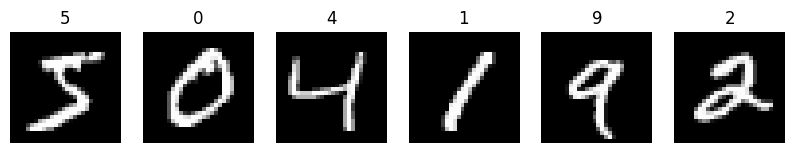


Starting Universal Cross-Validation (MNIST)...
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 5333
  Validation samples: 2667
  Train class distribution: 0: 530 (9.9%), 1: 604 (11.3%), 2: 526 (9.9%), 3: 540 (10.1%), 4: 532 (10.0%), 5: 468 (8.8%), 6: 532 (10.0%), 7: 569 (10.7%), 8: 502 (9.4%), 9: 530 (9.9%)
  Val class distribution:   0: 265 (9.9%), 1: 302 (11.3%), 2: 262 (9.8%), 3: 271 (10.2%), 4: 267 (10.0%), 5: 234 (8.8%), 6: 266 (10.0%), 7: 284 (10.6%), 8: 251 (9.4%), 9: 265 (9.9%)


2026-02-28 14:50:17.796284: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22804992 exceeds 10% of free system memory.
2026-02-28 14:50:17.796452: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22804992 exceeds 10% of free system memory.
2026-02-28 14:50:17.828437: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22804992 exceeds 10% of free system memory.
2026-02-28 14:50:17.829002: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22804992 exceeds 10% of free system memory.
2026-02-28 14:50:17.852771: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22804992 exceeds 10% of free system memory.


Fold 1 completed
  score: 0.9385
  accuracy: 0.9385
  balanced_accuracy: 0.9386
  f1_macro: 0.9379
  precision_macro: 0.9385
  recall_macro: 0.9386
  roc_auc_ovr_macro: 0.9967

Fold 2:
  Training samples: 5333
  Validation samples: 2667
  Train class distribution: 0: 530 (9.9%), 1: 604 (11.3%), 2: 525 (9.8%), 3: 541 (10.1%), 4: 533 (10.0%), 5: 468 (8.8%), 6: 532 (10.0%), 7: 568 (10.7%), 8: 502 (9.4%), 9: 530 (9.9%)
  Val class distribution:   0: 265 (9.9%), 1: 302 (11.3%), 2: 263 (9.9%), 3: 270 (10.1%), 4: 266 (10.0%), 5: 234 (8.8%), 6: 266 (10.0%), 7: 285 (10.7%), 8: 251 (9.4%), 9: 265 (9.9%)
Fold 2 completed
  score: 0.9325
  accuracy: 0.9325
  balanced_accuracy: 0.9310
  f1_macro: 0.9314
  precision_macro: 0.9341
  recall_macro: 0.9310
  roc_auc_ovr_macro: 0.9953

Fold 3:
  Training samples: 5334
  Validation samples: 2666
  Train class distribution: 0: 530 (9.9%), 1: 604 (11.3%), 2: 525 (9.8%), 3: 541 (10.1%), 4: 533 (10.0%), 5: 468 (8.8%), 6: 532 (10.0%), 7: 569 (10.7%), 8: 502 (9

In [21]:
# -------------------------
# Step A) Load MNIST
# -------------------------
from trustcv import ClassDistributionLogger  # fold-wise label distribution logging

(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

N = 8000  # smaller subset for speed (increase to 60000 for full MNIST train set)
x = (x_train[:N].astype("float32") / 255.0)[..., None]  # (N, 28, 28, 1)
y = y_train[:N].astype("int32")

print("X:", x.shape, "y:", y.shape, "classes:", np.unique(y))

# Show a few images (sanity check)
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x[i, :, :, 0], cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.show()


# -------------------------
# Step B) Keras model factory (CNN)
# -------------------------
def build_mnist_cnn():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


# -------------------------
# Step C) CV splitter (stratified by digit label)
# -------------------------
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


# -------------------------
# Step D) Runner + callback (class distribution logger)
# -------------------------
runner = UniversalCVRunner(cv_splitter=cv_splitter, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(labels=y, verbose=1, decimals=1)

model = KerasSkWrap(build_mnist_cnn, epochs=2, batch_size=64, verbose=0)

print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=model,
    data=(x, y),
    callbacks=[class_logger]
)

# Optional: peek at aggregated metrics (depends on TrustCV version output format)
try:
    print("\nFold-wise results keys:", results.keys())
except Exception:
    pass



# Summary: what you proved with this notebook

You can now show (to users/reviewers/colleagues) that TrustCV supports deep learning CV end-to-end:

- **Group leakage detection** with `TrustCVValidator` (bad vs good splitters)
- **Per-fold reporting** with `UniversalCVRunner`
- **Multi-input** (`dict` or `list`) without extra wrappers
- **Multi-label** (sigmoid C outputs)
- **Regression**
- **Multi-output** with `output_key` selection
- **Custom `train_step`** with dataset training while keeping CV automatic

If you want, I can also generate a **mini unit-test notebook cell** (pytest-style in notebook) that asserts:
- patient_overlap==0 for group-safe CV
- predictions shapes are correct for binary/multilabel/regression/multioutput
